# Customer Profitability & Sales Analytics

## Exploratory Data Analysis and Data Preparation

### Project Overview

This project analyzes the Sample Superstore dataset to understand the structure, quality, and characteristics of retail transaction data before performing business analysis.

The notebook focuses on exploring the dataset, assessing data quality, preparing the data for analysis, and creating additional features that support business intelligence and dashboard development.

The cleaned dataset produced in this notebook serves as the foundation for subsequent business performance analysis, customer analytics, and Power BI dashboard creation.

# Business Problem

Retail businesses generate thousands of sales transactions across different products, customers, regions, and shipping methods.

Although large amounts of transactional data are available, organizations often struggle to answer key business questions such as:

- Which products generate the highest profit?
- Which customer segments contribute the most revenue?
- How do discounts affect profitability?
- Which regions perform best?
- How has business performance changed over time?

Before these questions can be answered, the dataset must first be evaluated for quality, consistency, and completeness.

This notebook establishes a reliable analytical foundation for business decision-making.

# Project Objectives

The objectives of this notebook are to:

- Understand the structure of the dataset
- Assess data quality
- Identify missing values and duplicate records
- Examine numerical and categorical variables
- Convert date variables into datetime format
- Engineer additional analytical features
- Prepare a clean dataset for downstream business analysis

# Dataset Description

The Sample Superstore dataset contains historical retail transactions from a fictional office supply company.

Each transaction includes information related to:

- Customer details
- Product details
- Sales
- Profit
- Discount
- Quantity
- Shipping information
- Geographic location

The dataset will be used throughout this project to perform business intelligence and customer analytics.

# Project Workflow

The complete analytical workflow followed in this project is shown below.

Raw Dataset
        ↓
Data Exploration
        ↓
Data Quality Assessment
        ↓
Data Preparation
        ↓
Feature Engineering
        ↓
Exploratory Data Analysis
        ↓
Business Performance Analysis
        ↓
Customer Analytics
        ↓
Power BI Dashboard

# Analytical Mindset

Many exploratory data analysis projects focus on describing what happened.

This project goes one step further by investigating why certain business patterns exist and how those findings can support business decisions.

Throughout this project, every major analysis follows the same analytical process:

Business Question

↓

Initial Hypothesis

↓

Data Exploration

↓

Evidence

↓

Business Insight

↓

Recommendation

↓

Limitations

This approach ensures that conclusions are supported by data rather than assumptions.

In [110]:
# ------------------------------
# Import Required Libraries
# ------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Import Dataset

The Superstore dataset is loaded into a Pandas DataFrame.

The first step is to inspect the raw transactional data before any preprocessing or analysis is performed.

In [129]:
df = pd.read_csv("../data/Sample_Superstore.csv", encoding="latin1")

# Preview Dataset

The first few rows provide an initial understanding of the dataset structure, available variables, and transaction-level granularity.

In [130]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


# Dataset Dimensions

Understanding the number of observations and features helps estimate the overall size and complexity of the dataset.

In [98]:
rows, columns = df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 9,994
Columns: 21


# Dataset Information

This section examines:

- Data types
- Non-null values
- Memory usage

This helps identify columns that require preprocessing before analysis.

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## Why This Matters

Before performing business analysis, it is essential to verify that the dataset is complete and suitable for analysis.

The inspection confirms that the dataset contains customer, product, sales, and geographic information with no major structural issues.

This provides confidence that subsequent analyses will be based on reliable transactional data.

---

# Data Quality Assessment

Before conducting exploratory analysis, it is important to evaluate the quality of the dataset.

This section verifies:

- Available features
- Summary statistics
- Missing values
- Duplicate records
- Unique values

Performing these checks ensures that the dataset is complete, reliable, and suitable for further business analysis.

## Feature Overview

Understanding the available columns helps identify the information captured within the dataset and determines which variables will be useful for business analysis.

In [99]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

### Business Interpretation

Reliable data is a prerequisite for trustworthy business recommendations.

As the dataset contains **no missing values** and **no duplicate records**, it is suitable for analysis without requiring additional cleaning. This ensures that the insights and recommendations are based on complete and reliable data.

In [113]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.00,4997.50,1.00,2499.25,4997.50,7495.75,9994.00,2885.16
Order Date,9994,2016-04-30 00:07:12.259355,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,2016-05-03 23:06:58.571142,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Postal Code,9994.00,55190.38,1040.00,23223.00,56430.50,90008.00,99301.00,32063.69
Sales,9994.00,229.86,0.44,17.28,54.49,209.94,22638.48,623.25
Quantity,9994.00,3.79,1.00,2.00,3.00,5.00,14.00,2.23
Discount,9994.00,0.16,0.00,0.00,0.20,0.20,0.80,0.21
Profit,9994.00,28.66,-6599.98,1.73,8.67,29.36,8399.98,234.26
Order Year,9994.00,2015.72,2014.00,2015.00,2016.00,2017.00,2017.00,1.12
Order Quarter,9994.00,2.88,1.00,2.00,3.00,4.00,4.00,1.06


### Insights

The descriptive statistics provide an initial understanding of the numerical variables.

Several variables show noticeable differences between their mean and median values, particularly **Sales** and **Profit**, suggesting the presence of potential outliers.

Before proceeding with the business analysis, these observations are verified using boxplots to determine whether they represent genuine business transactions or potential data quality issues.

# Outlier Check

The descriptive statistics suggested the presence of extreme observations in the Sales and Profit variables.

To verify this, boxplots are used to visualize the distribution of these variables before continuing with the analysis.

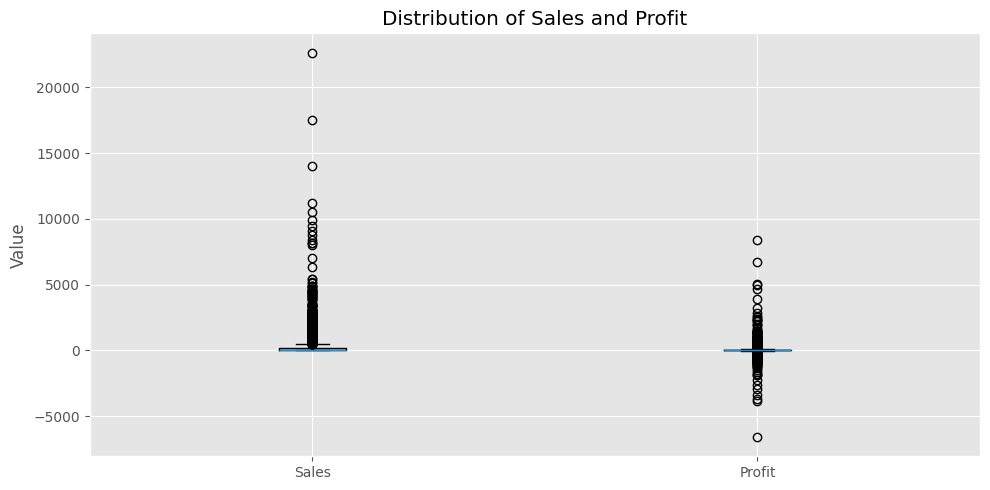

In [134]:
plt.figure(figsize=(10,5))

plt.boxplot(
    [df["Sales"], df["Profit"]],
    tick_labels=["Sales", "Profit"]
)

plt.title("Distribution of Sales and Profit")
plt.ylabel("Value")

plt.tight_layout()

plt.savefig(
    "../charts/sales_profit_boxplot.png",
    dpi=100,
    bbox_inches="tight"
)


plt.show()

### Observation

The boxplots confirm the presence of several extreme observations, particularly in Sales and Profit.

These observations are likely to represent legitimate high-value business transactions rather than data quality issues.

Therefore, all records were retained for subsequent analysis.

## Missing Value Analysis

Missing values can reduce analytical accuracy and may require preprocessing before analysis.

The following check verifies data completeness.

In [101]:
missing_values = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing_values

,Missing Values
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### Insights

No missing values are present in the dataset.

This indicates a complete dataset that does not require missing value treatment before analysis.

## Duplicate Record Analysis

Duplicate records can distort business metrics such as sales, profit, and customer counts.

This step checks whether duplicate transactions exist.

In [102]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


### Insights

No duplicate records were identified.

This suggests that each transaction is uniquely represented within the dataset.

## Unique Values by Feature

Understanding the number of unique values helps distinguish between categorical identifiers and analytical variables.

It also provides insight into dataset diversity.

In [103]:
unique_values = (
    df.nunique()
      .sort_values(ascending=False)
      .to_frame("Unique Values")
)

unique_values

,Unique Values
Row ID,9994
Profit,7287
Sales,5825
Order ID,5009
Product ID,1862
Product Name,1850
Ship Date,1334
Order Date,1237
Customer ID,793
Customer Name,793


### Insights

The dataset contains a diverse set of customers, products, locations, and orders.

This diversity enables detailed customer segmentation, regional analysis, and product-level performance evaluation.

## Business Question 1

Which product categories generate the highest sales and profit?

Understanding category performance helps identify which areas of the business contribute most to revenue and profitability.

In [117]:
category_summary = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Discount=("Discount", "mean"),
          Total_Orders=("Order ID", "count")
      )
      .round(2)
)

category_summary

,Total_Sales,Total_Profit,Average_Discount,Total_Orders
Category,,,,
Furniture,741999.80,18451.27,0.17,2121
Office Supplies,719047.03,122490.80,0.16,6026
Technology,836154.03,145454.95,0.13,1847


### Analyst Observation

- **Technology** is the best-performing category, generating the **highest sales (836.15K)** and the **highest profit (145.45K)** while maintaining the **lowest average discount (13%)**.

- **Office Supplies** ranks second in profitability, earning **122.49K** in profit despite generating lower sales than Furniture, indicating stronger profit efficiency.

- **Furniture** generates substantial revenue (**742.00K**) but produces only **18.45K** in profit. It also has the **highest average discount (17%)**, suggesting that aggressive discounting is reducing profitability.

### Business Interpretation

The analysis demonstrates that **high sales do not always translate into high profitability**. Although Furniture generates strong revenue, its heavy discounting significantly reduces profit margins. In contrast, Technology achieves both high sales and high profitability while maintaining lower discounts, making it the strongest-performing category. These findings suggest that the business should **optimize Furniture's pricing and discount strategy** to improve profitability rather than focusing solely on increasing sales.

## Business Question 2

Which regions contribute the highest business value?

In [118]:
region_summary = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Orders=("Order ID", "count")
      )
      .round(2)
)

region_summary

,Total_Sales,Total_Profit,Orders
Region,,,
Central,501239.89,39706.36,2323
East,678781.24,91522.78,2848
South,391721.90,46749.43,1620
West,725457.82,108418.45,3203


### Analyst Observation

- **West** is the highest-performing region, generating the **highest sales (725.46K)**, **highest profit (108.42K)**, and **highest number of orders (3,203)**.
- **East** ranks second in both sales (**678.78K**) and profit (**91.52K**), making it another strong-performing region.
- **Central** records higher sales than South but generates the **lowest profit ($39.71K)**, indicating weaker profitability.
- **South** has the lowest sales and order volume but achieves a slightly higher profit than Central, suggesting relatively better profit efficiency.

### Business Interpretation

The regional analysis indicates that **business performance varies across regions, not just in terms of sales but also profitability**. While the West and East regions are the primary contributors to both revenue and profit, the Central region underperforms despite generating moderate sales. This suggests that factors such as **discounting, product mix, or operational costs** may be reducing profitability. The business should **investigate the Central region's pricing and sales strategy to improve profit margins while continuing to strengthen high-performing regions like West and East.**

## Business Question 3

Which customer segment contributes the highest revenue and profit?

In [119]:
segment_summary = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales","sum"),
          Total_Profit=("Profit","sum"),
          Orders=("Order ID","count")
      )
      .round(2)
)

segment_summary

,Total_Sales,Total_Profit,Orders
Segment,,,
Consumer,1161401.34,134119.21,5191
Corporate,706146.37,91979.13,3020
Home Office,429653.15,60298.68,1783


### Analyst Observation

- **Consumer** is the highest-performing customer segment, generating the **highest sales (1.16M)**, **highest profit (134.12K)**, and **largest number of orders (5,191)**.

- **Corporate** ranks second, contributing **706.15K** in sales and **91.98K** in profit, indicating strong business value despite a lower order volume than the Consumer segment.

- **Home Office** records the **lowest sales (429.65K)**, **lowest profit (60.30K)**, and **fewest orders (1,783)**, making it the smallest contributor to overall business performance.

### Business Interpretation

The analysis shows that **customer value varies significantly across segments**. The **Consumer** segment is the primary driver of both revenue and profitability, making it the business's most valuable customer group. While the **Corporate** segment also contributes strong financial performance, the **Home Office** segment represents an opportunity for growth through targeted marketing, customer acquisition, and retention strategies. The business should continue strengthening the Consumer segment while identifying ways to increase engagement and sales within the Home Office segment.

## Business Question 4

Which sub-categories drive profit and which reduce profitability?

In [120]:
subcategory_summary = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales","sum"),
          Total_Profit=("Profit","sum")
      )
      .sort_values("Total_Profit")
      .round(2)
)

subcategory_summary

,Total_Sales,Total_Profit
Sub-Category,,
Tables,206965.53,-17725.48
Bookcases,114880.00,-3472.56
Supplies,46673.54,-1189.10
Fasteners,3024.28,949.52
Machines,189238.63,3384.76
Labels,12486.31,5546.25
Art,27118.79,6527.79
Envelopes,16476.40,6964.18
Furnishings,91705.16,13059.14


### Analyst Observation

- **Copiers** is the most profitable sub-category, generating **55.62K** in profit despite relatively lower sales than Phones, indicating exceptionally strong profit margins.

- **Phones**, **Accessories**, **Paper**, **Binders**, and **Chairs** are also strong profit contributors, generating both high sales and healthy profitability.

- **Tables** is the worst-performing sub-category, generating **206.97K** in sales but incurring a **17.73K loss**, making it the largest source of negative profitability.

- **Bookcases** and **Supplies** also report negative profits, suggesting that these products are sold with insufficient margins or excessive discounts.

### Business Interpretation

The analysis demonstrates that **high sales alone do not guarantee profitability at the product level**. While several sub-categories generate strong revenue and profit simultaneously, **Tables**, **Bookcases**, and **Supplies** reduce overall business performance by operating at a loss. These findings suggest that the business should **review pricing, discount policies, procurement costs, and inventory strategies for loss-making sub-categories while continuing to invest in high-profit products such as Copiers, Phones, and Accessories.**

# Transition to Customer-Level Analysis

The previous analysis focused on understanding business performance at the transaction level.

However, important business questions such as customer profitability, purchasing behaviour, customer retention, and cross-category purchasing require analysis at the customer level.

To support the next stage of the investigation, the transaction-level dataset is transformed into a customer-level analytical dataset by aggregating key business metrics for each customer.

This customer summary will serve as the analytical foundation for Notebook 2.

# Creating a Customer-Level Analytical Dataset

Each row in the original dataset represents a transaction.

For customer analytics, each row should represent one customer.

The following transformation aggregates transaction-level records into customer-level metrics that will support the remainder of the analysis.

In [125]:
customer_summary = (
    df.groupby("Customer ID")
      .agg({
          "Order ID":"count",
          "Profit":"sum",
          "Sales":"sum",
          "Discount":"mean",
          "Segment":"first",
          "Region":"first"
      })
      .rename(columns={
          "Order ID":"Total_Orders",
          "Profit":"Total_Profit",
          "Discount":"Avg_Discount"
      })
)

In [132]:
customer_summary.head()

,Total_Orders,Total_Profit,Sales,Avg_Discount,Segment,Region
Customer ID,,,,,,
AA-10315,11,-362.88,5563.56,0.09,Consumer,Central
AA-10375,15,277.38,1056.39,0.08,Consumer,West
AA-10480,12,435.83,1790.51,0.02,Consumer,South
AA-10645,18,857.80,5086.93,0.06,Consumer,East
AB-10015,6,129.35,886.16,0.07,Consumer,West


# Validate Customer-Level Dataset

Before exporting the analytical dataset, a final validation step is performed to confirm that the customer-level features have been created successfully.

The exported dataset will be used throughout Notebook 2 for customer analytics and business investigation.

In [133]:
customer_summary.head()

customer_summary.to_csv(
    "../data/customer_summary.csv",
    index=True
)

print("customer_summary.csv exported successfully.")

customer_summary.csv exported successfully.


# Notebook Summary

## What was accomplished?

This notebook explored and validated the Superstore dataset before transforming transaction-level records into a customer-level analytical dataset.

The work included:

- Data cleaning and validation
- Exploratory business analysis
- Category, region, segment, and product performance analysis
- Feature engineering
- Customer-level aggregation
- Creation of the `customer_summary.csv` dataset

The exported customer-level dataset provides the analytical foundation for Notebook 2, where customer purchasing behaviour, profitability, and strategic business questions are investigated in greater detail.

The transition from transaction-level exploration to customer-level analysis reflects a typical business analytics workflow, where exploratory analysis is followed by the creation of analysis-ready data for deeper business investigation.